In [4]:
# import library
import numpy as np
from scipy.stats import multivariate_normal
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

In [5]:
# 次元数
D = 2

# 平均パラメータ
mu_d = np.array([0.0, 10.0])
print(mu_d)

# 分散パラメータ
sigma2_dd = np.array([
  [9.0, 2.5],
  [2.5, 4.0]
])
print(sigma2_dd)


[ 0. 10.]
[[9.  2.5]
 [2.5 4. ]]


In [ ]:
k = 3.0
u = 5.0
x_0_size = np.sqrt(sigma2_dd[0, 0]) # 基準値を指定
x_1_size = np.sqrt(sigma2_dd[1, 1]) # 基準値を指定
x_0_size *= k # 定数倍
x_1_size *= k # 定数倍
x_0_size = np.ceil(x_0_size / u) * u # u単位で切り上げ
x_1_size = np.ceil(x_1_size / u) * u # u単位で切り上げ
x_0_min = mu_d[0] - x_0_size
x_0_max = mu_d[0] + x_0_size
x_1_min = mu_d[1] - x_1_size
x_1_max = mu_d[1] + x_1_size
print(x_0_min, x_0_max)
print(x_1_min, x_1_max)

# x軸の値を作成
x_0_vec = np.linspace(start=x_0_min, stop=x_0_max, num=251)
x_1_vec = np.linspace(start=x_1_min, stop=x_1_max, num=251)
print(x_0_vec[:5])
print(x_1_vec[:5])

-10.0 10.0
0.0 20.0
[-10.    -9.92  -9.84  -9.76  -9.68]
[0.   0.08 0.16 0.24 0.32]


In [11]:
# 格子点を作成
x_0_grid, x_1_grid = np.meshgrid(x_0_vec, x_1_vec)
print(x_0_grid)
print(x_1_grid)

# 格子点の座標を整形
x_arr = np.stack([x_0_grid.flatten(), x_1_grid.flatten()], axis=1)
x_dims = x_0_grid.shape
print(x_arr[:5])

[[-10.    -9.92  -9.84 ...   9.84   9.92  10.  ]
 [-10.    -9.92  -9.84 ...   9.84   9.92  10.  ]
 [-10.    -9.92  -9.84 ...   9.84   9.92  10.  ]
 ...
 [-10.    -9.92  -9.84 ...   9.84   9.92  10.  ]
 [-10.    -9.92  -9.84 ...   9.84   9.92  10.  ]
 [-10.    -9.92  -9.84 ...   9.84   9.92  10.  ]]
[[ 0.    0.    0.   ...  0.    0.    0.  ]
 [ 0.08  0.08  0.08 ...  0.08  0.08  0.08]
 [ 0.16  0.16  0.16 ...  0.16  0.16  0.16]
 ...
 [19.84 19.84 19.84 ... 19.84 19.84 19.84]
 [19.92 19.92 19.92 ... 19.92 19.92 19.92]
 [20.   20.   20.   ... 20.   20.   20.  ]]
[[-10.     0.  ]
 [ -9.92   0.  ]
 [ -9.84   0.  ]
 [ -9.76   0.  ]
 [ -9.68   0.  ]]


In [12]:
x_dims

(251, 251)

In [13]:
# xの値ごとに、ガウス分布に従う確率密度を計算
dens_grid = multivariate_normal.pdf(
  x=x_arr, mean=mu_d, cov=sigma2_dd
).reshape(x_dims)
print(dens_grid[150:155, 150:155].round(3))

[[0.017 0.017 0.017 0.017 0.016]
 [0.016 0.016 0.016 0.016 0.016]
 [0.016 0.016 0.016 0.015 0.015]
 [0.015 0.015 0.015 0.015 0.015]
 [0.015 0.014 0.014 0.014 0.014]]


In [15]:
# ラベル用の文字列を作成
tmp_mu_str = ', '.join([f'{mu:.1f}' for mu in mu_d])
tmp_sgm_0_str = ', '.join([f'{sgm:.1f}' for sgm in sigma2_dd[0, :]])
tmp_sgm_1_str = ', '.join(f'{sgm:.1f}' for sgm in sigma2_dd[1, :])
param_lbl = f'$\\mu = ({tmp_mu_str}), '
param_lbl += f'\\Sigma = \\binom{{{tmp_sgm_0_str}}}{{{tmp_sgm_1_str}}}$'
print(param_lbl)

$\mu = (0.0, 10.0), \Sigma = \binom{9.0, 2.5}{2.5, 4.0}$


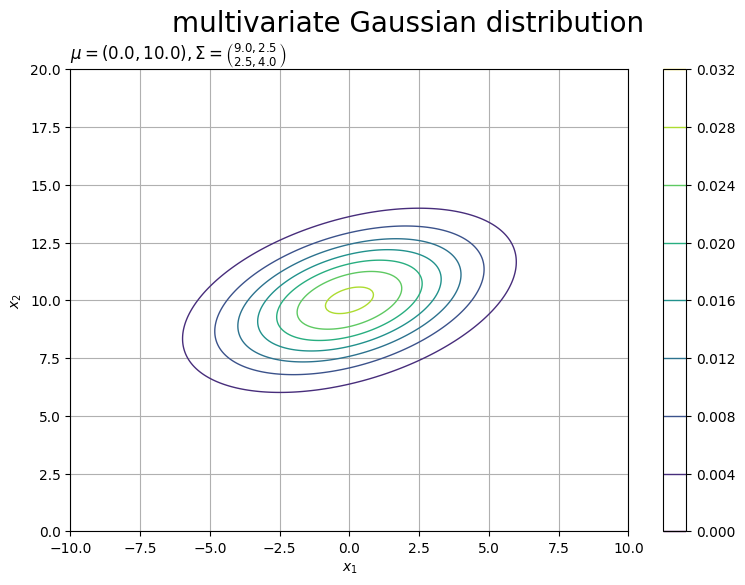

In [18]:
# ガウス分布を作画
plt.figure(figsize=(9, 6), dpi=100, facecolor='white')
plt.contour(
  x_0_grid, x_1_grid, dens_grid,
  linewidths=1.0
) # 等高線
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title(param_lbl, loc='left')
plt.suptitle('multivariate Gaussian distribution', fontsize=20)
plt.colorbar()
plt.grid()
plt.show()

/var/folders/yn/rx1lyty16dnfrgwgqmk04h4m0000gn/T/ipykernel_17436/3075389779.py:3: UserWarning: linewidths is ignored by contourf
  plt.contourf(


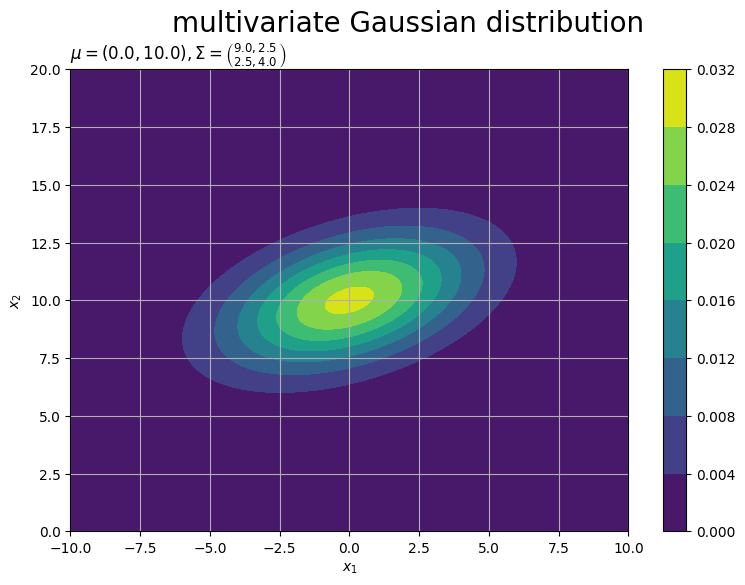

In [19]:
# ガウス分布を作画
plt.figure(figsize=(9, 6), dpi=100, facecolor='white')
plt.contourf(
  x_0_grid, x_1_grid, dens_grid,
  linewidths=1.0
) # 等高線
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.title(param_lbl, loc='left')
plt.suptitle('multivariate Gaussian distribution', fontsize=20)
plt.colorbar()
plt.grid()
plt.show()

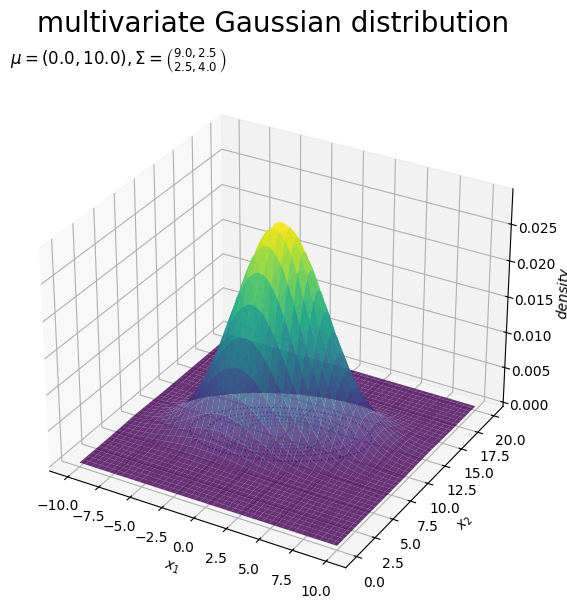

In [20]:
# ガウス分布を作画
fig, ax = plt.subplots(
  figsize=(9, 6), dpi=100, facecolor='white',
  constrained_layout=True, subplot_kw={'projection': '3d'}
)
fig.suptitle('multivariate Gaussian distribution', fontsize=20)
ax.contour(
  x_0_grid, x_1_grid, Z=dens_grid, offset=0.0,
  linewidths=1.0, linestyles=':'
) # 等高線
ax.plot_surface(
  X=x_0_grid, Y=x_1_grid, Z=dens_grid,
  cmap='viridis', alpha=0.8
)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$density$')
ax.set_title(param_lbl, loc='left')
plt.show()